<!-- Add this to the first cell of your notebook with cell type set to "Raw" -->
<style>
  /* Main document styling */
  body {
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.5;
    background-color: #f8f9fa;
    color: #212529;
  }

  /* Headers */
  h1 {
    color: #2c3e50;
    border-bottom: 2px solid #3498db;
    padding-bottom: 0.3em;
    font-size: 2.2em;
  }

  h2 {
    color: #3498db;
    border-left: 3px solid #3498db;
    padding-left: 10px;
    font-size: 1.8em;
  }

  h3 {
    color: #2980b9;
    font-size: 1.5em;
  }

  /* Code cells */
  div.input_area {
    background-color: #f8f8f8;
    border-left: 5px solid #3498db;
  }

  /* Output cells */
  div.output_area {
    background-color: #ffffff;
    border-left: 5px solid #2ecc71;
    padding: 10px;
  }

  /* Markdown cells */
  div.text_cell_render {
    padding: 15px;
    border-radius: 5px;
    background-color: white;
    box-shadow: 0 1px 3px rgba(0,0,0,0.12), 0 1px 2px rgba(0,0,0,0.24);
    margin-bottom: 15px;
  }

  /* Highlight key findings */
  .key-finding {
    background-color: #e8f4f8;
    padding: 10px;
    border-left: 4px solid #3498db;
    margin: 15px 0;
  }

  /* Tables */
  table {
    border-collapse: collapse;
    width: 100%;
    margin: 20px 0;
  }

  th, td {
    padding: 12px;
    text-align: left;
    border-bottom: 1px solid #ddd;
  }

  th {
    background-color: #3498db;
    color: white;
  }

  tr:hover {
    background-color: #f5f5f5;
  }

  /* Equations */
  .MathJax {
    color: #2c3e50 !important;
  }

  /* Info boxes */
  .info-box {
    background-color: #d4edda;
    color: #155724;
    padding: 15px;
    border-radius: 5px;
    margin: 20px 0;
    border-left: 5px solid #28a745;
  }

  .warning-box {
    background-color: #fff3cd;
    color: #856404;
    padding: 15px;
    border-radius: 5px;
    margin: 20px 0;
    border-left: 5px solid #ffc107;
  }

  .error-box {
    background-color: #f8d7da;
    color: #721c24;
    padding: 15px;
    border-radius: 5px;
    margin: 20px 0;
    border-left: 5px solid #dc3545;
  }
</style>

# 🧬 Predicting Geographical Origins from Genetic Markers

**Team Members:** Hamidou Diallo & Imane

## Introduction

This study explores the relationship between genetic markers and geographical origins of indigenous peoples from North, Central, and South America. Using statistical learning techniques, we aim to build predictive models that can determine an individual's geographical coordinates (latitude and longitude) based solely on their genetic profile.

The dataset comprises 494 individuals from various tribes across the Americas, each characterized by 5,709 genetic markers encoded as binary variables (1 for mutation presence, 0 for absence). The high dimensionality of this dataset presents significant statistical challenges, as the number of predictors (p) far exceeds the number of observations (N).

To address this challenge, we implement Principal Component Regression (PCR), a two-step approach that:
1. Reduces the dimensionality of genetic markers through Principal Component Analysis (PCA)
2. Uses the resulting principal components as predictors in a linear regression model

Throughout this analysis, we carefully consider methodological issues including:
- Data leakage prevention through appropriate cross-validation strategies
- Optimal model complexity selection to balance bias and variance
- Geographic distance metrics that account for Earth's curvature
- The effect of data preprocessing on model performance

This work has implications for anthropology, population genetics, and our understanding of human migration patterns throughout the Americas.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics.pairwise import haversine_distances
from math import radians
import statsmodels.api as sm
from scipy import stats
import itertools

### Exercice 1: Data Visualization

For the data visualization exercise, the map of America displaying tribal locations provides a
 clear geographical representation of what our model aims to predict. I've supplemented this
 visualization with statistical descriptions to better understand the dataset's
 characteristics.

Text(83.17879444959422, 0.5, 'Latitude')

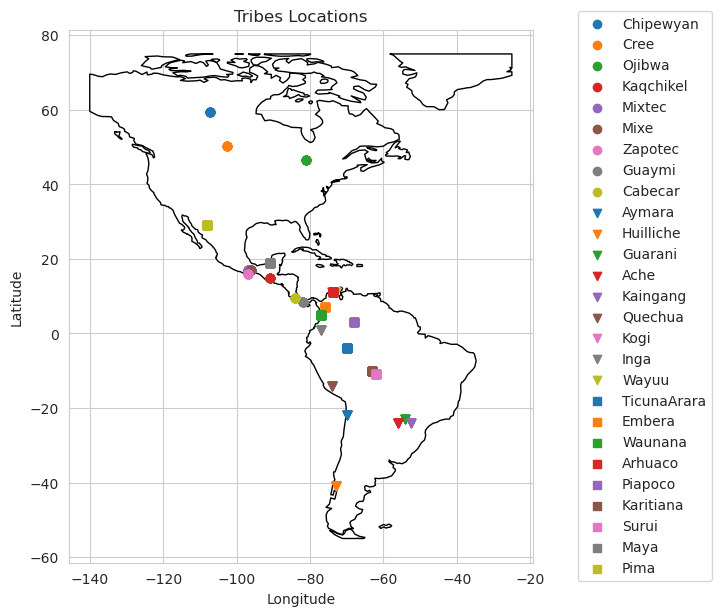

In [11]:
# Load the data
file_path = 'NAm2.txt'
df_original = pd.read_csv(file_path, delimiter=' ')

df_copie = df_original.copy()

# Extract relevant columns
latitude = df_copie.iloc[:, 6]
longitude = df_copie.iloc[:, 7]
tribes = df_copie.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df_copie, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

**Let's analyze our data set before making a model.**

In [4]:
# Preparing data for stat analysis
df_modified = df_copie.drop(df_original.columns[0:7], axis=1)

# Overview
print("===============Data Info=========================================\n")
display(df_original.info())
print("=================================================================\n")
print("===============Description of the date set=======================\n")
display(df_original.describe())
# Null value
print("===============Checking null value===============================\n")
display(df_original.isnull().sum())
print("===============Overviewing the head data=========================\n")
display(df_original.head())
print("=================================================================\n")
print(f"Dimension: {df_original.shape}")



===============Data Info=========================================

<class 'pandas.core.frame.DataFrame'>
Index: 494 entries, Chipewyan29 to Pima1051
Columns: 5717 entries, IndivID to L678.218
dtypes: float64(2), int64(5712), object(3)
memory usage: 21.6+ MB


None


===============Description of the date set=======================



,IndivID,PopID,sex,lat,long,L1.125,L1.130,L1.135,L1.140,L1.142,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
count,494.000000,494.000000,494.0,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,...,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000
mean,2064.495951,668.153846,0.0,8.451194,-80.973279,0.002024,0.002024,0.002024,0.002024,0.002024,...,0.107287,0.263158,0.212551,0.004049,0.006073,0.046559,0.040486,0.888664,0.014170,0.004049
std,649.805868,309.406342,0.0,24.159398,15.441783,0.044992,0.044992,0.044992,0.044992,0.044992,...,0.309792,0.440794,0.409527,0.063564,0.077770,0.210905,0.197296,0.314867,0.118311,0.063564
min,702.000000,81.000000,0.0,-41.000000,-108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.250000,811.000000,0.0,-10.000000,-96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,2157.500000,831.000000,0.0,9.500000,-77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2543.750000,838.000000,0.0,17.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2800.000000,849.000000,0.0,59.550000,-52.500000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


===============Checking null value===============================



IndivID                  0
PopID                    0
Pop                      0
Country                  0
Continent                0
                        ..
L678.206                 0
L678.209.848101265823    0
L678.210                 0
L678.214                 0
L678.218                 0
Length: 5717, dtype: int64

===============Overviewing the head data=========================



,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,0
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,0
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,1,0,0,0,0,0,1,0,0



Dimension: (494, 5717)


#### Key Observations:
- The dataset contains a significantly larger number of predictors (p = 5709) compared to observations (N = 494), which presents statistical challenges as discussed in class.
- This high-dimensional feature space creates potential risks of overfitting and estimation problems in our modeling approach.
- However, various methodologies exist to address these challenges effectively.

The visual representation helps contextualize our prediction task geographically, while the statistical analysis reveals the dimensional challenges we'll need to overcome in subsequent exercises.

### Exercice 2: Multiple linear regression


##### a) *response*
We want to estimate the coefficients of the multiple linear regression, based on the expression :
$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

In [5]:
X_matrix_predictors = df_modified.iloc[:, 1:]
X_matrix_predictors['intercept'] = 1
y_pred = df_modified.iloc[:, 0]

try:
    np.linalg.solve(X_matrix_predictors.T.dot(X_matrix_predictors), X_matrix_predictors.T.dot(y_pred))
except np.linalg.linalg.LinAlgError:
    print(f'{np.linalg.linalg.LinAlgError}')
    print('It did not work.')

<class 'numpy.linalg.LinAlgError'>
It did not work.


In [6]:
rank_X = np.linalg.matrix_rank(X_matrix_predictors)
print(f"Rank de X: {rank_X}")
print(f"Number of predictors (p): {X_matrix_predictors.shape[1]}")
print(f"does the rank(X) < p? {rank_X < X_matrix_predictors.shape[1]}")

Rank de X: 494
Number of predictors (p): 5710
does the rank(X) < p? True


**Mathematical interpretation**: When p > N (number of predictors exceeds number of observations), the matrix $X^T X$ is singular (not invertible), which means there's no unique solution to the normal equations. This is a fundamental problem in high-dimensional statistics with several important implications:

1. The rank of matrix X is at most N, making $X^T X$ rank-deficient when p > N
2. This rank deficiency creates an infinite number of possible solutions to the regression problem
3. The condition is exacerbated by multicollinearity among the genetic markers
4. This mathematical constraint explains why we encountered an error when attempting to use `numpy.linalg.solve`

##### b) *answer*



In [7]:
beta = np.linalg.lstsq(X_matrix_predictors, y_pred, rcond=None)[0]


R-squared: 1.0000
Mean Squared Error: 0.0000


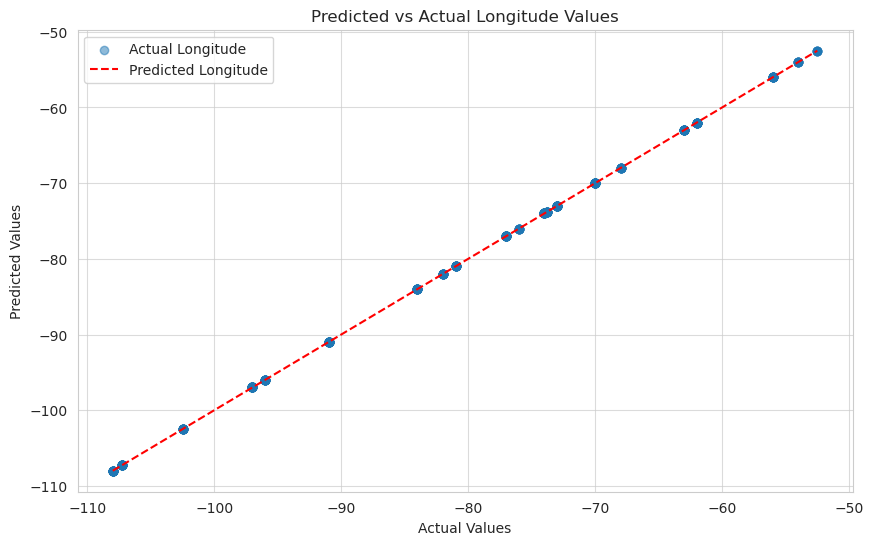

In [8]:
# Using the beta coefficients to make predictions
X_pred = X_matrix_predictors
y_pred_actual = y_pred
y_pred_model = X_pred @ beta

# Calculate R-squared to assess the goodness of fit
SS_total = np.sum((y_pred_actual - np.mean(y_pred_actual))**2)
SS_residual = np.sum((y_pred_actual - y_pred_model)**2)
r_squared = 1 - (SS_residual / SS_total)

print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Squared Error
mse = np.mean((y_pred_actual - y_pred_model)**2)
print(f"Mean Squared Error: {mse:.4f}")

# Visualize predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_actual, y_pred_model, alpha=0.5)
plt.plot([y_pred_actual.min(), y_pred_actual.max()],[y_pred_actual.min(), y_pred_actual.max()], 'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Longitude Values')
plt.grid(True, alpha=0.7)
plt.legend(['Actual Longitude', 'Predicted Longitude'])
plt.show()

**Key Differences Between numpy.linalg.solve and numpy.linalg.lstsq**

- **numpy.linalg.solve**: Solves the equation $Ax=b$ only when A is a square, invertible matrix. This requires a unique solution to exist, which is impossible in our case where p > N.

- **numpy.linalg.lstsq**: Finds the solution that minimizes $\lVert Ax-b \rVert^{2}$ (the sum of squared residuals), even when A is not of full rank. It uses Singular Value Decomposition (SVD) to compute a solution, making it more robust and appropriate for overdetermined or underdetermined systems.

In our high-dimensional genetic dataset, lstsq provides a valid solution despite the rank deficiency by finding the minimum-norm solution among the infinite possible solutions. This is why we were able to successfully compute coefficients with lstsq but not with solve.

***Critical Analysis of Model Evaluation***

The perfect R-squared (R = 1) isn't an overfitting problem in the traditional sense - it's a mathematical consequence of how we're evaluating the model:

1. **Same Data Issue**: We're using the same data to both compute beta and evaluate its performance. This is not a valid test of the model's predictive ability.

2. **Rank Considerations**: With p > N (5709 predictors vs 494 observations), the least squares solution can always perfectly reproduce the training data - it's a mathematical certainty, not a meaningful result.

3. **No Cross-Validation**: Without separating training and test data, we can't evaluate how well the model actually generalizes.

The correct approach would be to:
- Split data into training and test sets
- Compute beta on the training set only
- Evaluate performance on the held-out test set

This would reveal the true (and likely much lower) predictive performance of the model.
Now i see question c ;)

##### c) *answer*

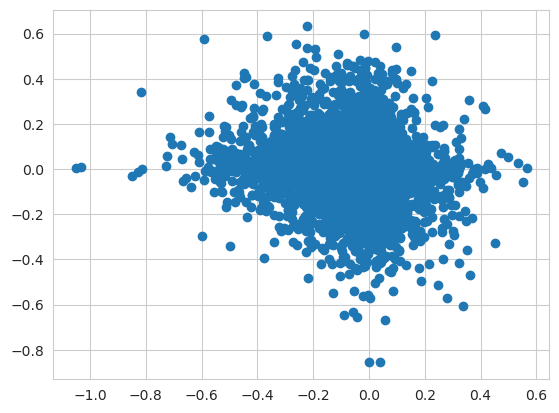

In [12]:
# select only the genetic markers as predictors
predictors = df_original.columns[8:]    # create the design matrix
X = df_original[predictors].values      # get the observed values to predict
y = df_original['long']

# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

beta_coef = beta[1:]


plt.scatter(beta_coef, lr.coef_);


The reason sklearn centers predictors is to make the intercept interpretable as the expected value of y when all predictors are at their means. Without centering, the intercept would represent the expected value of y when all predictors are zero, which might not be meaningful in many contexts.



**Interpretation:**
- When predictors are centered, the intercept represents the expected value of y when all predictors are at their means
- When predictors are not centered, the intercept represents the expected value of y when all predictors are zero

So it's normal to not have a diagonal line on the scatter, because we didn't recenter the beta.

### Exercice 3: Principal components analysis

##### a) PCA:
PCA is a dimensionality reduction technique that transforms a set of correlated variables into a set of uncorrelated variables called principal components:

- Geometric interpretation: PCA finds the directions (eigenvectors) in which the data varies the most. These directions become the principal components.
- Statistical interpretation: PCA finds linear combinations of original variables that maximize variance. The first principal component accounts for as much of the variability as possible, and each succeeding component accounts for as much of the remaining variability as possible while being orthogonal to the preceding components.

##### b) *answer*

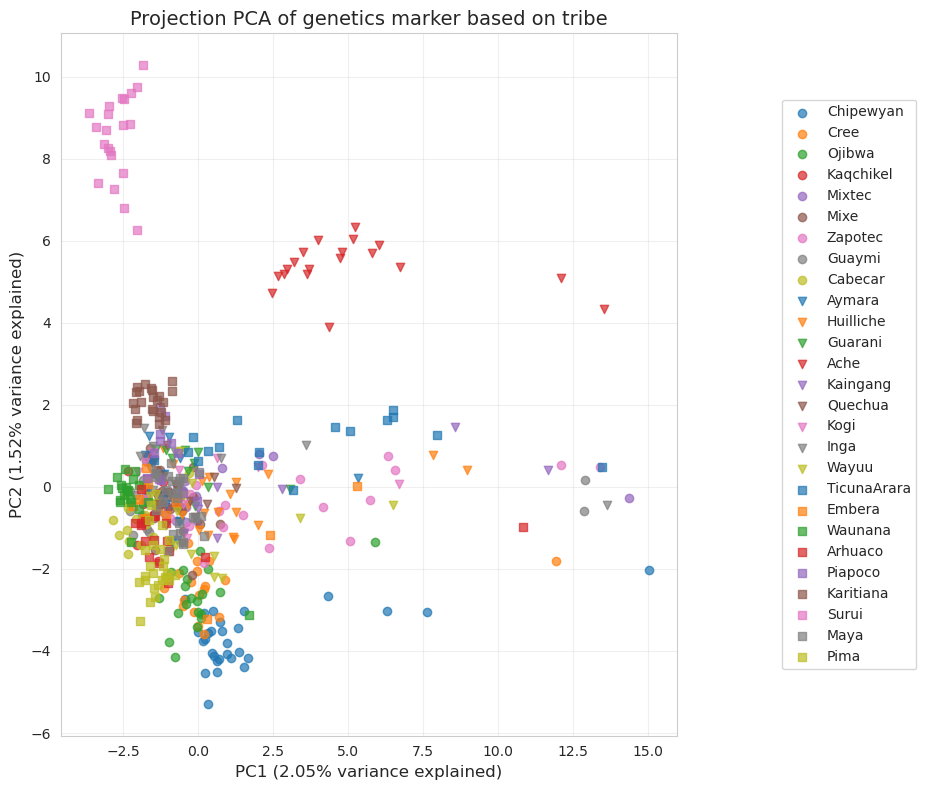

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(df_copie['Pop'].unique()):

    tribe_indices = df_copie['Pop'] == tribe


    plt.scatter(
        X_pca[tribe_indices, 0],
        X_pca[tribe_indices, 1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe,
        alpha=0.7
    )


plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)', fontsize=12)
plt.title('Projection PCA of genetics marker based on tribe', fontsize=14)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**:
The plot shows distinct clustering patterns of different tribes in the PCA space, which suggests that genetic markers contain information about tribal affiliation and potentially geographical origin.

**Critical observation**: The first two principal components explain only a very small fraction of the total variance - less than 3% combined. This extremely low explained variance has important implications:

1. Despite explaining minimal variance, these components still manage to capture meaningful tribal clustering, indicating that even small genetic variations can be informative of population structure

2. The vast majority of genetic variation (>97%) is not visualized in this plot, meaning potentially important patterns remain hidden in higher dimensions

3. The partial tribe mixing we observe might be resolved by examining additional principal components that capture other aspects of genetic variation

This surprisingly low explained variance yet visible clustering suggests that the genetic signal differentiating tribes is subtle but distinct, concentrated in specific markers rather than distributed across the entire genome.

##### c + d) ***answer***

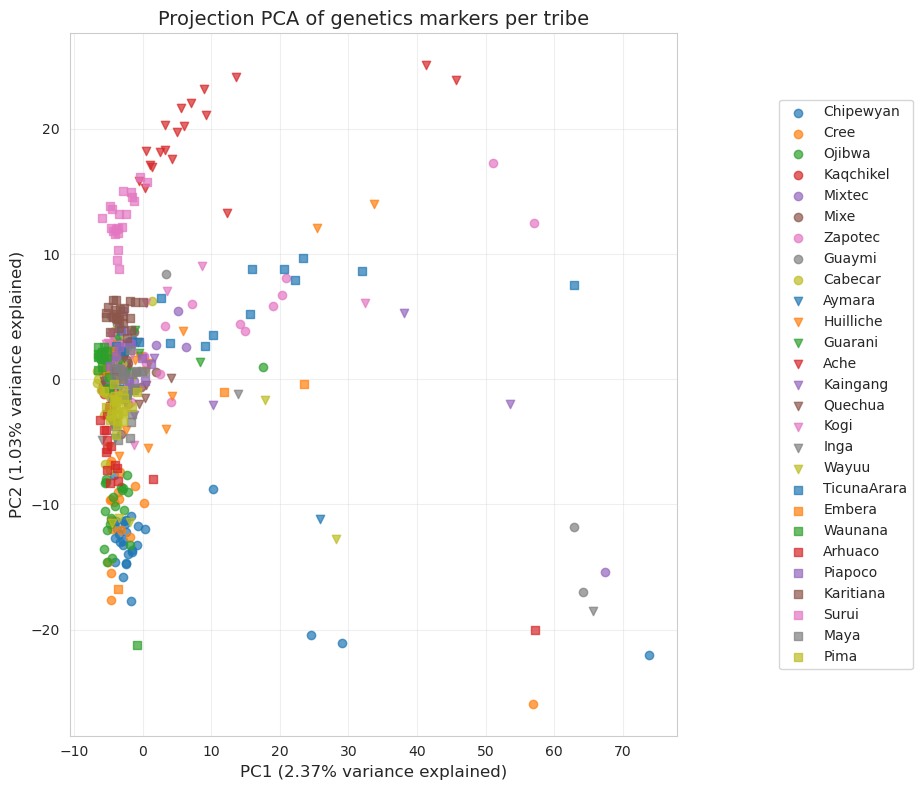

In [15]:
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

plt.figure(figsize=(10, 8))
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(df_copie['Pop'].unique()):

    tribe_indices = df_copie['Pop'] == tribe


    plt.scatter(
        X_pca_std[tribe_indices, 0],
        X_pca_std[tribe_indices, 1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe,
        alpha=0.7
    )


plt.xlabel(f'PC1 ({pca_std.explained_variance_ratio_[0]:.2%} variance explained)', fontsize=12)
plt.ylabel(f'PC2 ({pca_std.explained_variance_ratio_[1]:.2%} variance explained)', fontsize=12)
plt.title('Projection PCA of genetics markers per tribe', fontsize=14)
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Effect of Standardization on PCA**:

When standardizing the data causes the tribal clusters from the original PCA to disappear, this reveals something fundamental about our genetic marker data:

- Why the Clusters Disappeared

    - ****Scale dominance****: In the original data (without standardization), certain genetic markers likely had larger variances than others, we can see it from exercice 1, on the description of the data. These high-variance markers dominated the PCA, creating the tribal separation we observed.
    - ****Variance equalization****: Standardization gives equal weight to all genetic markers by scaling them to unit variance. When all markers contribute equally to the PCA, the previously dominant patterns are diluted.
    - ****Information distribution****: This suggests that the tribal clustering was primarily driven by a subset of genetic markers with larger variances, rather than being a pattern distributed across all markers.

- Mathematical Explanation
The disappearance of clusters after standardization indicates that:

    - The genetic markers that best distinguish between tribes had naturally larger variances
    - When forced to contribute equally through standardization, the distinctive tribal signals become mixed with noise from less informative markers

##### e) ***answer***


310
0.049039559288078294


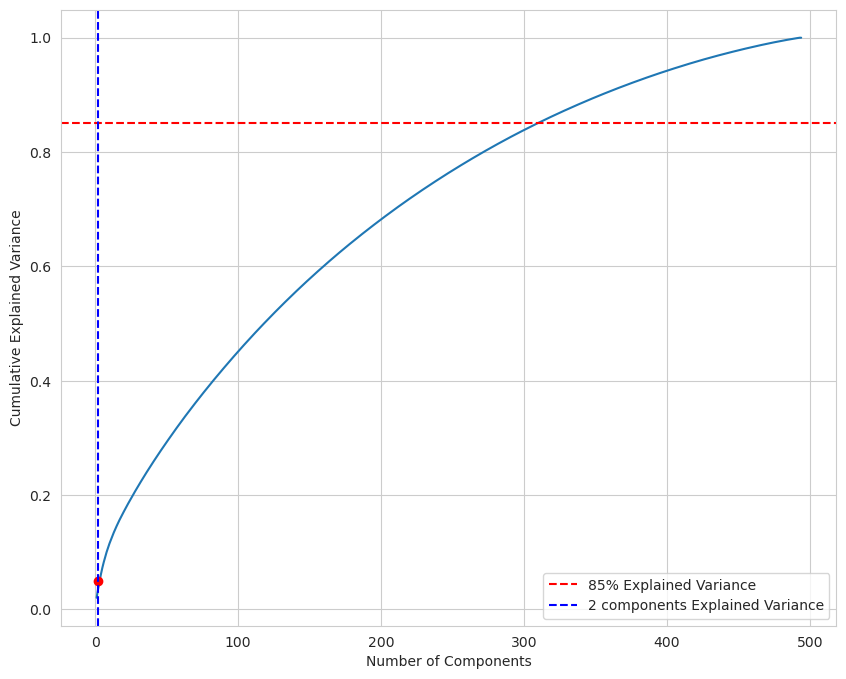

In [17]:
pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.85) +1
print(n_components)
print(cumulative_variance[2])

plt.figure(figsize=(10, 8))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Explained Variance')
plt.plot(2, cumulative_variance[2], 'ro')
plt.axvline(x=2, color='b', linestyle='--', label='2 components Explained Variance')
plt.legend()
plt.show()

****Interpretation :****
- When number_components = 310 we have more than 85% of the variance explained by our new predictors.
- When the number of components is equal to 2, the purcentage of variance is 4.9%, which is too low.

### Exercice 4: Principal components regression


##### a) ***answer***

In [18]:
pca = PCA(n_components=250)
X_pca = pca.fit_transform(X)

# To predict latitude
lat_model = LinearRegression()
lat_model.fit(X_pca, df_original['lat'])
lat_pred = lat_model.predict(X_pca)

# To predict longitude
long_model = LinearRegression()
long_model.fit(X_pca, df_original['long'])
long_pred = long_model.predict(X_pca)


# Create a DataFrame with predicted coordinates
predicted_coords = pd.DataFrame({
    'lat_pred': lat_pred,
    'long_pred': long_pred,
    'Pop': df_original['Pop']  # Tribe information for coloring
})

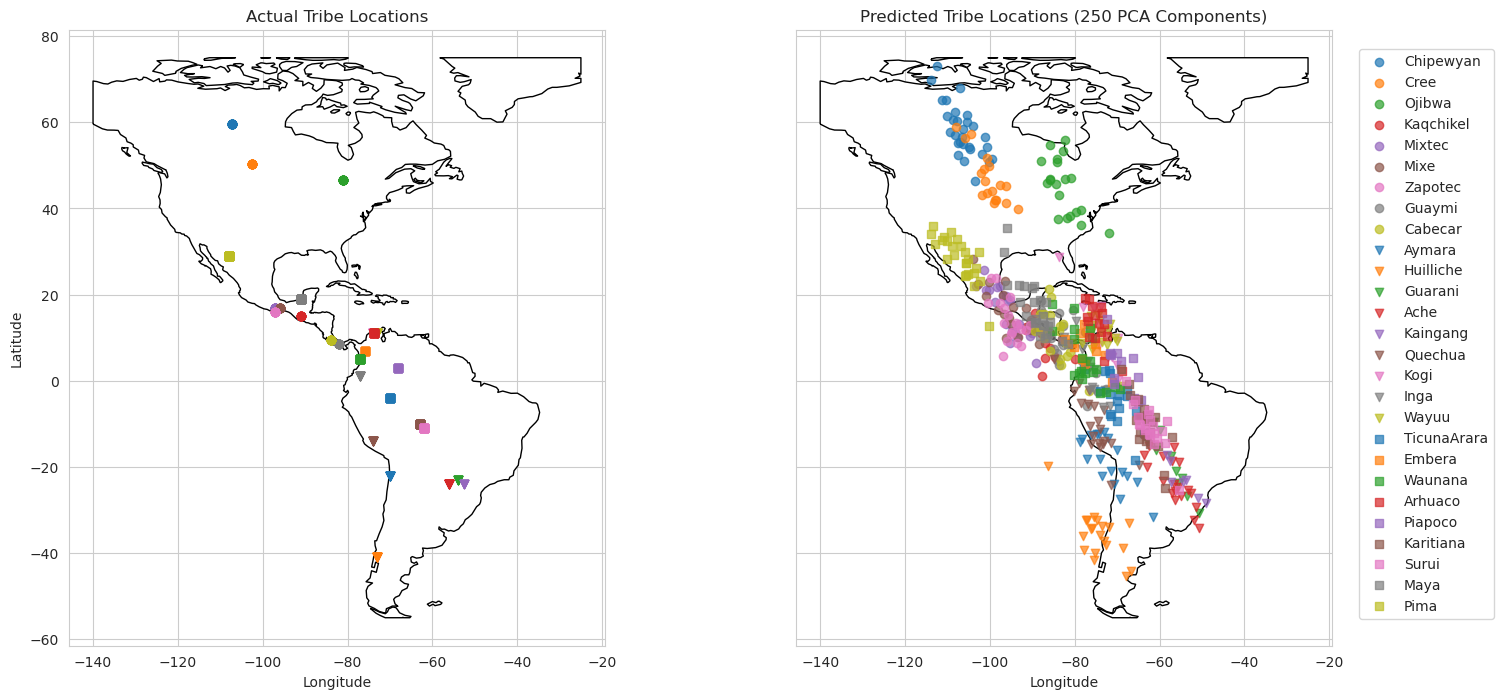

In [19]:
# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)
plt.subplots_adjust(left=0.05, right=0.95, wspace=0.02)

# Common map background for both plots
for ax in axes:
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    ax.set_xlabel('Longitude')

# Set specific titles and y-axis label
axes[0].set_title('Actual Tribe Locations')
axes[0].set_ylabel('Latitude')
axes[1].set_title('Predicted Tribe Locations (250 PCA Components)')

# Plot actual locations in left subplot
for i, tribe in enumerate(df_copie['Pop'].unique()):
    members_tribe = df_copie[df_copie['Pop'] == tribe]
    axes[0].scatter(members_tribe['long'], members_tribe['lat'],
                   marker=marker_list[i//9],
                   color=colors_list[i%9],
                   label=tribe,
                   alpha=0.7)

# Plot predicted locations in right subplot
for i, tribe in enumerate(df_copie['Pop'].unique()):
    indices = df_copie['Pop'] == tribe
    axes[1].scatter(long_pred[indices], lat_pred[indices],
                   marker=marker_list[i//9],
                   color=colors_list[i%9],
                   label=tribe,
                   alpha=0.7)

# Add a single legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.0, 0.5))

plt.show()

**Critical Analysis of Prediction Maps**

Examining the comparison between actual tribe locations (left) and predicted locations (right), we can observe several important patterns:

**Evidence of Data Leakage Effects**

Despite using the same dataset for PCA transformation, model training, and evaluation (which should theoretically lead to artificially good predictions), we still observe:
- Significant spreading of predicted locations compared to the concentrated actual locations
- Substantial mixing of tribal predictions, particularly in central regions
- General preservation of north-south patterns but with much less precision

**Fundamental Limitations Revealed**

This visualization demonstrates that even with methodological advantages from data leakage:
1. Genetic markers alone cannot precisely predict geographic origins
2. The relationship between genetics and geography is fundamentally imprecise
3. Historical migration patterns and population mixing have likely obscured geographic signals in genetic data

**Methodological Context**

While our approach suffers from:
- Using the same data for feature extraction and evaluation
- Potential overfitting with 250 components for 494 observations

The visible dispersion in predictions suggests these methodological issues aren't masking the fundamental limitations - they're revealing them.

**Conclusion**

This visualization provides valuable insight: even under idealized conditions with data leakage advantages, genetic markers offer limited precision for geographic prediction. Exercise 5 will help quantify these limitations more rigorously through proper cross-validation.

##### b) ***answer***

In [20]:
def convert_to_radians(lat, long):
    return np.c_[np.radians(lat), np.radians(long)]

In [21]:
actual_coords_rad = convert_to_radians(df_original['lat'], df_original['long'])

predicted_coords_rad = convert_to_radians(lat_pred, long_pred)

distances_rad = haversine_distances(actual_coords_rad, predicted_coords_rad)

earth_radius_km = 6371
distance_km = distances_rad * earth_radius_km

mean_distance_km = np.mean(np.diag(distance_km))
print(f"Mean distance between actual and predicted coordinates: {mean_distance_km:.2f} km")

Mean distance between actual and predicted coordinates: 654.17 km


**Understanding the High Average Error**

The high average error of 619.20 km aligns with our observations from the visualization in part (a). Despite the methodological advantages from using the same data for PCA transformation and model training (which should artificially improve performance), we still observe substantial prediction errors.

This large error (equivalent to the distance between major cities) reveals fundamental limitations in genetic-based geographic prediction:

1. **Scale Perspective**: While the model preserves broad continental patterns, it lacks precision at regional scales - individuals could be predicted to be in entirely different countries from their actual origins

2. **Inherent Limitations**: Even with 250 principal components (which risks overfitting), the model cannot achieve high geographic precision, suggesting:
   - The relationship between genetic markers and geography is inherently imprecise
   - Historical population movements have diluted geographic signals in genetic data
   - Complex, non-linear relationships exist that linear models cannot adequately capture
   - Shared genetic markers across distant populations due to ancient migration patterns create ambiguity

3. **Methodological Implications**: The high error despite data leakage advantages suggests that even idealized conditions cannot overcome the fundamental limitations of this prediction task

This error magnitude provides quantitative evidence that genetic markers alone cannot precisely predict geographic origins, even when methodological advantages would tend to inflate performance.

### Exercice 5: PCR and Cross-validation

##### a) ***answer***

**Cross-validation**

Cross-validation is a resampling procedure used to evaluate models on limited data. Given a dataset with N observations, k-fold cross-validation involves:

1. Dividing the dataset into k equal-sized folds
2. For each of the k folds:
   - Train the model using k-1 folds (training set)
   - Evaluate the model on the remaining fold (test set)
3. Average the k performance metrics to get a more robust estimate of model performance

This approach is particularly valuable because:
- It provides a more reliable estimate of model performance on unseen data
- Each observation is used for both training and testing
- The variance of the estimated performance is reduced

As we saw in Exercise 4, using the same data for both training and testing leads to overfitting and data leakage, resulting in overly optimistic performance estimates. Cross-validation helps mitigate these issues by ensuring model evaluation is performed on data not used during training.

For non-IID data (where observations are not independent and identically distributed), standard k-fold cross-validation may be inappropriate. Alternative strategies include:

- Stratified k-fold: Maintains the same proportion of target classes in each fold (for classification)
- Group k-fold: Ensures observations from the same group (e.g., same individual or tribe) stay together
- Time-series split: For temporal data, trains on past observations and tests on future ones
- Leave-one-group-out: Leaves out one group at a time, useful when observations naturally cluster

##### b) ***answer***

##### ***Cross validation iterators:***
Based on the structure of our dataset, the most appropriate cross-validation iterator would be Group k-fold. This choice is justified by several characteristics of our data:

1. The data is organized by tribes, with individuals from the same tribe likely having similar genetic markers due to shared ancestry.

2. The exercise specifically mentions that the order of rows in the dataframe might be significant, suggesting that samples are grouped by tribe or geographical region.

3. In this genetic study context, we want to evaluate how well our model generalizes to entirely new tribes or populations, rather than just new individuals from already-seen tribes.

Group k-fold ensures that all samples from the same tribe are either entirely in the training set or entirely in the test set for each fold. This prevents data leakage between tribes and provides a more realistic assessment of how our model would perform when predicting the geographical origin of individuals from previously unseen tribal populations.

Using standard KFold would be inappropriate as it might split tribes across training and testing sets, leading to artificially inflated performance metrics and not properly evaluating the model's generalization capabilities.

##### c) ***answer*** -> Evaluating the quality of the PCR(4)

In [22]:
pca = PCA(n_components=410)
lr = LinearRegression()
est = make_pipeline(pca, lr)

cv = GroupKFold(n_splits=10)
groups = df_original['Pop']

y_coords = df_original[['lat', 'long']].values

train_errors = []
test_errors = []


In [23]:
for train_index, test_index in cv.split(X, y_coords, groups=groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_coords[train_index], y_coords[test_index]


    est.fit(X_train, y_train)

    y_train_pred = est.predict(X_train)
    y_test_pred = est.predict(X_test)

    y_train_rad = np.radians(y_train)
    y_train_pred_rad = np.radians(y_train_pred)
    y_test_rad = np.radians(y_test)
    y_test_pred_rad = np.radians(y_test_pred)

    train_distances = haversine_distances(y_train_rad, y_train_pred_rad).diagonal() * 6371
    test_distances = haversine_distances(y_test_rad, y_test_pred_rad).diagonal() * 6371

    train_errors.append(np.mean(train_distances))
    test_errors.append(np.mean(test_distances))

# Overall mean errors
mean_train_error = np.mean(train_errors)
mean_test_error = np.mean(test_errors)

print(f"Mean training error: {mean_train_error:.2f} km")
print(f"Mean test error: {mean_test_error:.2f} km")

Mean training error: 186.87 km
Mean test error: 2034.21 km


##### d) ***answer*** -> Quality for n_components between 2 and 440

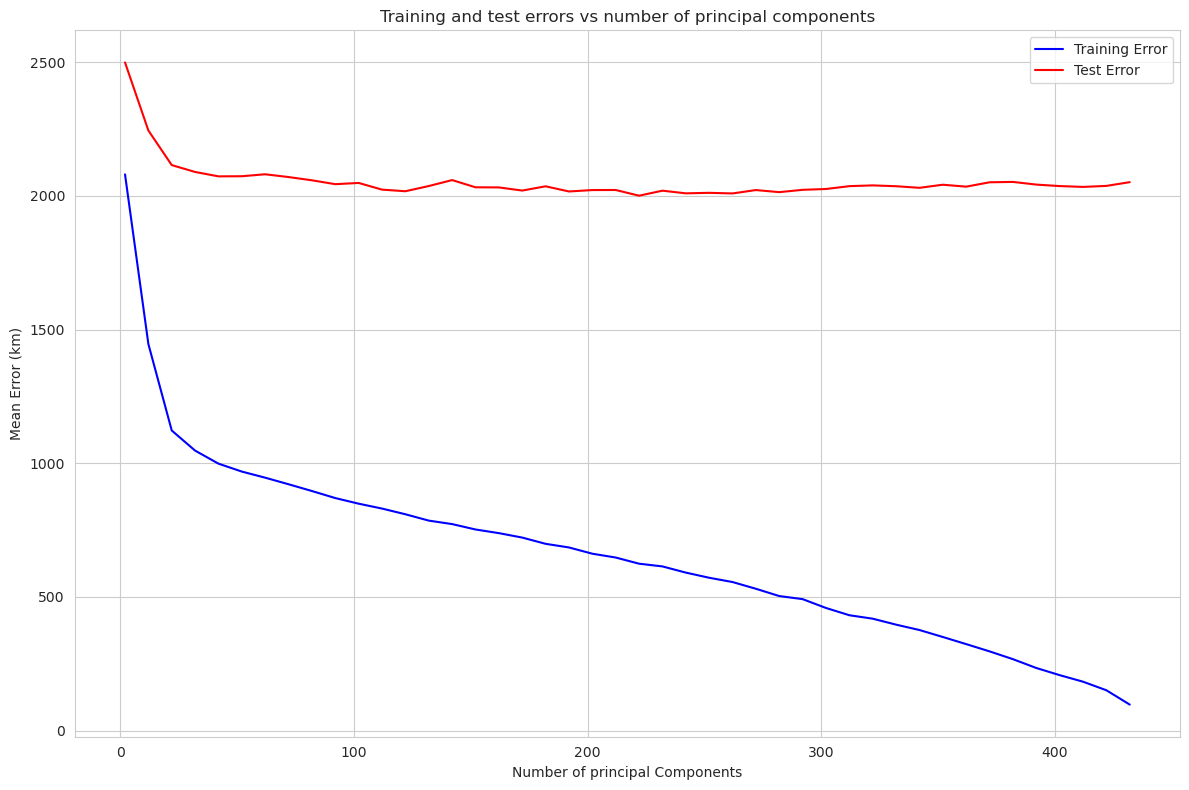

In [24]:
train_errors_mean = []
test_errors_mean = []
for n_components in range(2, 440, 10):
    pca = PCA(n_components=n_components)
    lr = LinearRegression()
    est = make_pipeline(pca, lr)

    cv = GroupKFold(n_splits=10)
    groups = df_original['Pop']

    y_coords = df_original[['lat', 'long']].values

    train_errors = []
    test_errors = []

    for train_index, test_index in cv.split(X, y_coords, groups=groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_coords[train_index], y_coords[test_index]


        est.fit(X_train, y_train)

        y_train_pred = est.predict(X_train)
        y_test_pred = est.predict(X_test)

        y_train_rad = np.radians(y_train)
        y_train_pred_rad = np.radians(y_train_pred)
        y_test_rad = np.radians(y_test)
        y_test_pred_rad = np.radians(y_test_pred)

        train_distances = haversine_distances(y_train_rad, y_train_pred_rad).diagonal() * 6371
        test_distances = haversine_distances(y_test_rad, y_test_pred_rad).diagonal() * 6371

        train_errors.append(np.mean(train_distances))
        test_errors.append(np.mean(test_distances))

    train_errors_mean.append(np.mean(train_errors))
    test_errors_mean.append(np.mean(test_errors))


components_range = list(range(2, 440, 10))

plt.figure(figsize=(12, 8))
plt.plot(components_range, train_errors_mean, 'b-', label='Training Error')
plt.plot(components_range, test_errors_mean, 'r-', label='Test Error')
plt.xlabel('Number of principal Components')
plt.ylabel('Mean Error (km)')
plt.title('Training and test errors vs number of principal components')
plt.legend()
plt.tight_layout()

##### e) ***answer***


Optimal number of components: 222
Minimum test error: 2000.50 km
Corresponding training error: 624.00 km


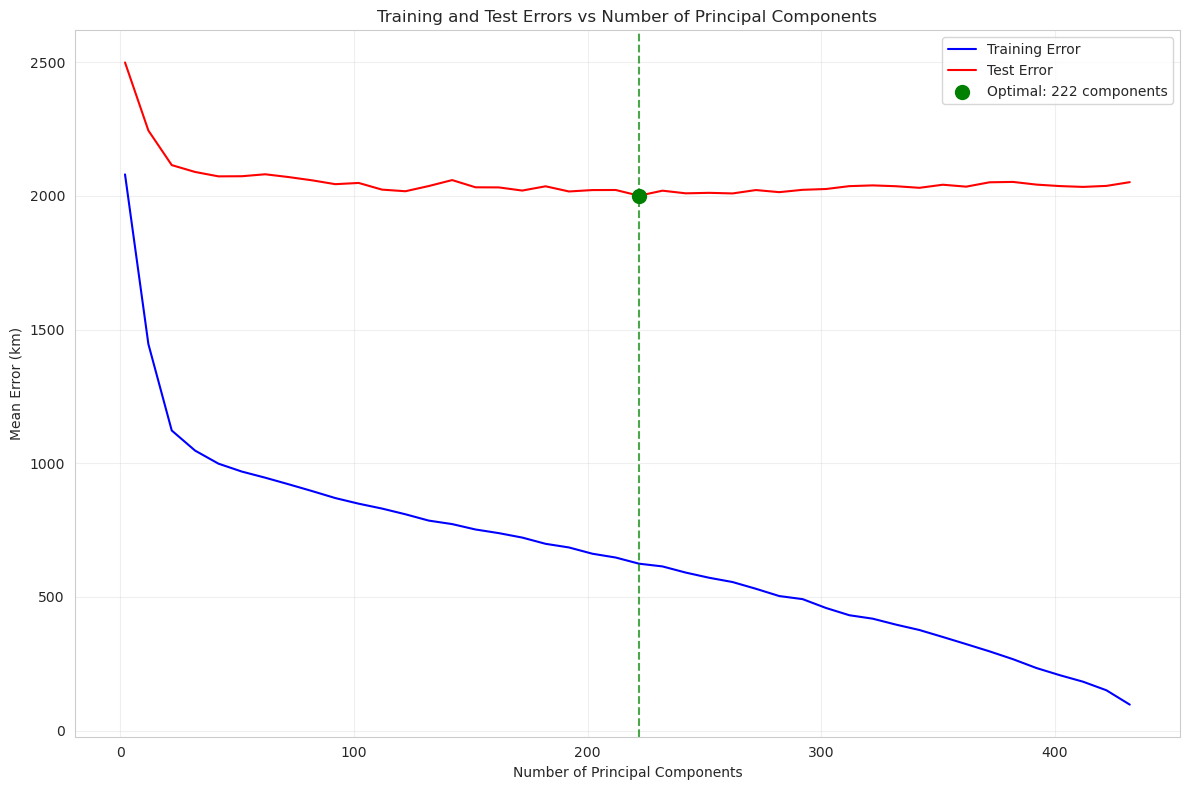


Overall mean distance error (optimal model): 663.92 km


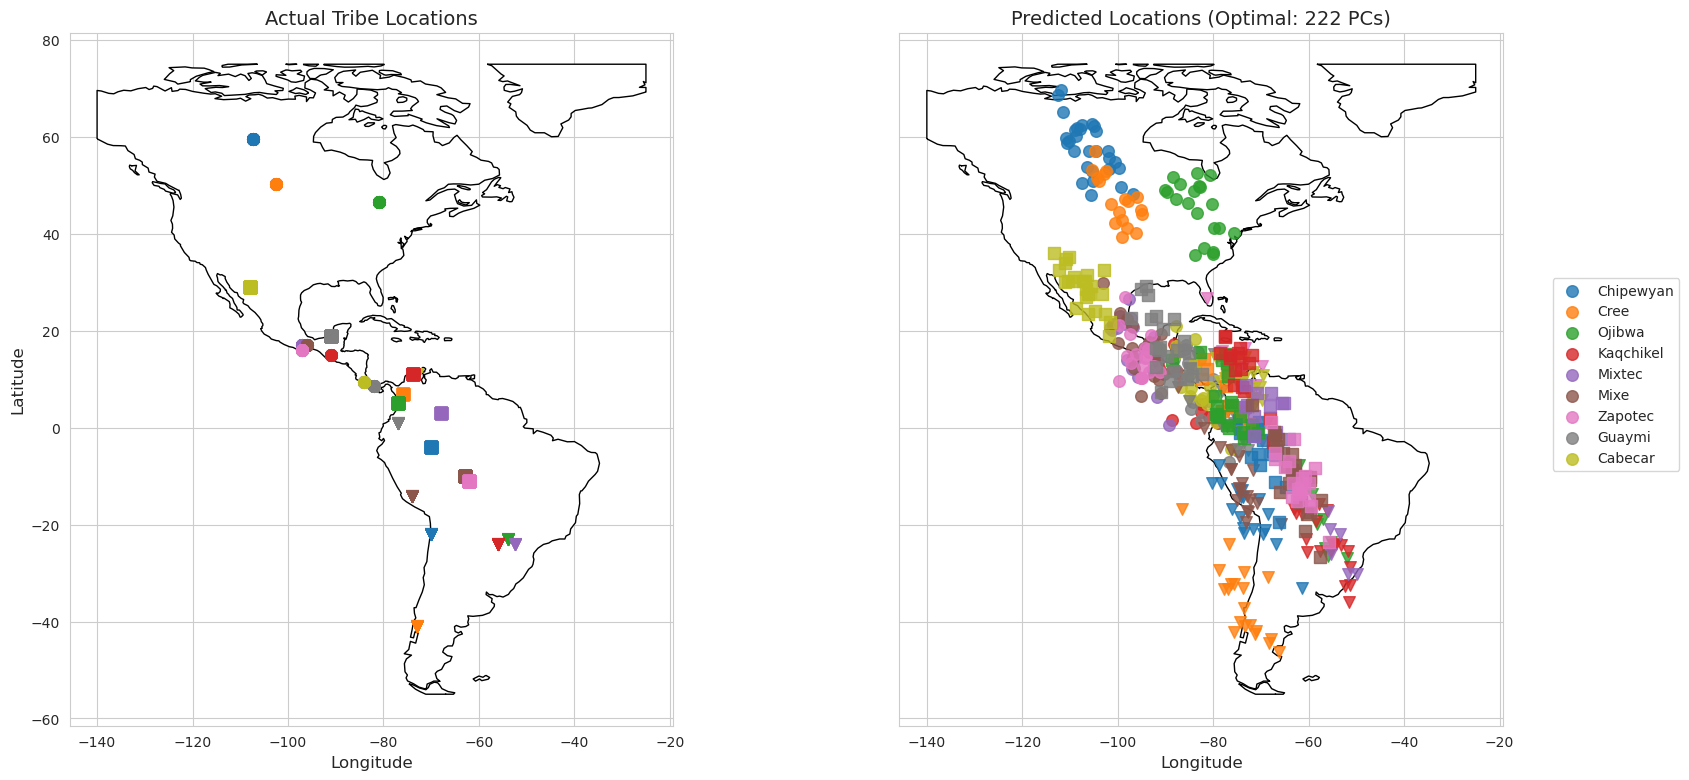


Prediction Errors by Tribe:
                    mean         min          max         std  count
Pop                                                                 
Wayuu         435.747682  113.807404   795.827470  203.191065     17
Pima          495.369400  138.578770  1279.864870  303.445606     25
Surui         514.561653   98.182722  1558.143259  414.623083     21
Zapotec       528.415450  123.634017  1237.671399  262.222965     19
Inga          565.887483   79.630719  1618.502862  456.528724     17
Piapoco       582.466443  174.047338  1403.745912  305.526468     13
Chipewyan     583.438133  106.356904  1430.214651  386.822125     29
TicunaArara   595.342920  174.033694  1775.107356  429.627190     17
Arhuaco       597.220498  142.938515  1706.358784  400.749700     17
Embera        599.169305  223.292829  1013.768834  277.199939     11
Kogi          643.119877  167.626739  1905.077887  494.844475     17
Cabecar       647.400597  167.145268  1763.809375  417.172212     20
Cree 

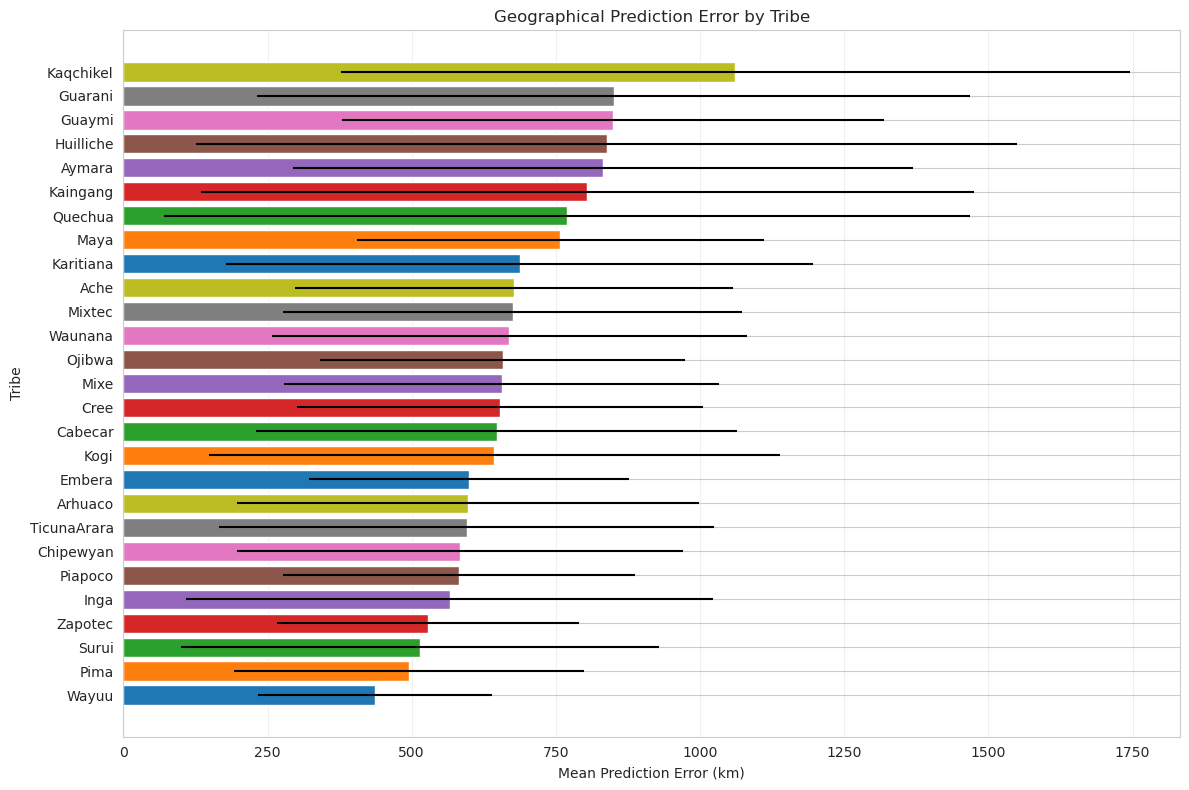

In [25]:


# Components and their corresponding test errors
components_range = list(range(2, 440, 10))
test_errors_mean = np.array(test_errors_mean)


optimal_idx = np.argmin(test_errors_mean)
optimal_components = components_range[optimal_idx]
min_test_error = test_errors_mean[optimal_idx]

print(f"Optimal number of components: {optimal_components}")
print(f"Minimum test error: {min_test_error:.2f} km")
print(f"Corresponding training error: {train_errors_mean[optimal_idx]:.2f} km")

# Plot with the optimal point highlighted
plt.figure(figsize=(12, 8))
plt.plot(components_range, train_errors_mean, 'b-', label='Training Error')
plt.plot(components_range, test_errors_mean, 'r-', label='Test Error')
plt.scatter([optimal_components], [min_test_error], s=100, c='green', zorder=5,
           label=f'Optimal: {optimal_components} components')
plt.axvline(x=optimal_components, color='g', linestyle='--', alpha=0.7)
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Error (km)')
plt.title('Training and Test Errors vs Number of Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Train the optimal model on the full dataset
optimal_model = make_pipeline(PCA(n_components=optimal_components), LinearRegression())
optimal_model.fit(X, df_original[['lat', 'long']])

# Make predictions
y_pred = optimal_model.predict(X)
lat_pred = y_pred[:, 0]
long_pred = y_pred[:, 1]

# Calculate overall error
actual_coords_rad = convert_to_radians(df_original['lat'], df_original['long'])
predicted_coords_rad = convert_to_radians(lat_pred, long_pred)
distances_rad = haversine_distances(actual_coords_rad, predicted_coords_rad)
earth_radius_km = 6371
distance_km = distances_rad * earth_radius_km
mean_distance_km = np.mean(np.diag(distance_km))
print(f"\nOverall mean distance error (optimal model): {mean_distance_km:.2f} km")

# Create a DataFrame with predicted coordinates
predicted_coords = pd.DataFrame({
    'lat_pred': lat_pred,
    'long_pred': long_pred,
    'actual_lat': df_original['lat'],
    'actual_long': df_original['long'],
    'error_km': np.diag(distance_km),
    'Pop': df_original['Pop']  # Tribe information for coloring
})



# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)
plt.subplots_adjust(left=0.05, right=0.95, wspace=0.05)

# Get world map data
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# Common map background for both plots
for ax in axes:
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    ax.set_xlabel('Longitude', fontsize=12)

# Set specific titles and y-axis label
axes[0].set_title('Actual Tribe Locations', fontsize=14)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[1].set_title(f'Predicted Locations (Optimal: {optimal_components} PCs)', fontsize=14)

# Marker and color settings
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Plot actual locations in left subplot
for i, tribe in enumerate(df_original['Pop'].unique()):
    tribe_indices = df_original['Pop'] == tribe
    axes[0].scatter(df_original.loc[tribe_indices, 'long'],
                   df_original.loc[tribe_indices, 'lat'],
                   marker=marker_list[i//9],
                   color=colors_list[i%9],
                   label=tribe if i < 9 else "_",  # Only label first 9 for clarity
                   alpha=0.8, s=70)

# Plot predicted locations in right subplot
for i, tribe in enumerate(df_original['Pop'].unique()):
    tribe_indices = df_original['Pop'] == tribe
    axes[1].scatter(predicted_coords.loc[tribe_indices, 'long_pred'],
                   predicted_coords.loc[tribe_indices, 'lat_pred'],
                   marker=marker_list[i//9],
                   color=colors_list[i%9],
                   label="_",  # Don't add to legend
                   alpha=0.8, s=70)

# Add a single legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.0, 0.5),
          fontsize=10, frameon=True)

plt.show()

# Add an analysis of prediction errors by tribe
tribe_errors = predicted_coords.groupby('Pop')['error_km'].agg(['mean', 'min', 'max', 'std', 'count'])
tribe_errors = tribe_errors.sort_values(by='mean')

# Display tribe-specific errors
print("\nPrediction Errors by Tribe:")
print(tribe_errors)

# Visualize tribe-specific errors
plt.figure(figsize=(12, 8))
plt.barh(tribe_errors.index, tribe_errors['mean'], xerr=tribe_errors['std'],
        color=[colors_list[i%9] for i in range(len(tribe_errors))])
plt.xlabel('Mean Prediction Error (km)')
plt.ylabel('Tribe')
plt.title('Geographical Prediction Error by Tribe')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



In [26]:
from ipywidgets import interact, widgets

def plot_tribe_predictions(tribe='All'):
    fig, ax = plt.subplots(figsize=(12, 10))
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

    if tribe == 'All':
        tribe_filter = slice(None)  # All rows
    else:
        tribe_filter = predicted_coords['Pop'] == tribe

    # Plot actual positions
    ax.scatter(predicted_coords.loc[tribe_filter, 'actual_long'],
               predicted_coords.loc[tribe_filter, 'actual_lat'],
               color='blue', marker='o', label='Actual', alpha=0.7)

    # Plot predicted positions
    ax.scatter(predicted_coords.loc[tribe_filter, 'long_pred'],
               predicted_coords.loc[tribe_filter, 'lat_pred'],
               color='red', marker='x', label='Predicted', alpha=0.7)

    # Connect actual and predicted with lines
    for idx in predicted_coords.loc[tribe_filter].index:
        ax.plot([predicted_coords.loc[idx, 'actual_long'], predicted_coords.loc[idx, 'long_pred']],
                [predicted_coords.loc[idx, 'actual_lat'], predicted_coords.loc[idx, 'lat_pred']],
                'k-', alpha=0.2)

    ax.set_title(f'Actual vs Predicted Locations: {tribe}', fontsize=14)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.legend()
    plt.tight_layout()

    if tribe != 'All':
        mean_error = predicted_coords.loc[tribe_filter, 'error_km'].mean()
        print(f"Mean prediction error for {tribe}: {mean_error:.2f} km")

    return fig

# Create dropdown for tribes
tribe_options = ['All'] + sorted(predicted_coords['Pop'].unique().tolist())
interact(plot_tribe_predictions, tribe=widgets.Dropdown(options=tribe_options, value='All'));

interactive(children=(Dropdown(description='tribe', options=('All', 'Ache', 'Arhuaco', 'Aymara', 'Cabecar', 'C…

In [28]:

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np


# This function will create an interactive dashboard
def create_model_explorer(components_range, train_errors, test_errors, predicted_coords, df_original):

    # Create the output widget where we'll display our plots and statistics
    output = widgets.Output()

    # Create tab structure for different analyses
    tab = widgets.Tab()
    tab_overview = widgets.Output()
    tab_maps = widgets.Output()
    tab_tribes = widgets.Output()
    tab_components = widgets.Output()

    tab.children = [tab_overview, tab_maps, tab_tribes, tab_components]
    tab.set_title(0, 'Overview')
    tab.set_title(1, 'Map Comparison')
    tab.set_title(2, 'Tribal Analysis')
    tab.set_title(3, 'Components Analysis')

    # Widget for selecting tribe
    tribe_selector = widgets.Dropdown(
        options=['All Tribes'] + sorted(df_original['Pop'].unique().tolist()),
        value='All Tribes',
        description='Tribe:',
        style={'description_width': 'initial'}
    )

    # Widget for selecting number of components
    component_slider = widgets.IntSlider(
        value=np.argmin(test_errors)+1,
        min=1,
        max=len(components_range),
        step=1,
        description='Component Index:',
        style={'description_width': 'initial'}
    )

    # Display component value
    component_value = widgets.Label()

    def update_component_value(change):
        idx = change['new'] - 1
        component_value.value = f"Components: {components_range[idx]} | Test Error: {test_errors[idx]:.2f} km"

    component_slider.observe(update_component_value, names='value')
    update_component_value({'new': component_slider.value})

    # OVERVIEW TAB
    with tab_overview:
        # Find optimal components
        optimal_idx = np.argmin(test_errors)
        optimal_components = components_range[optimal_idx]
        min_test_error = test_errors[optimal_idx]

        # Model summary statistics
        display(HTML(f"""
        <div style="background-color: #f8f9fa; padding: 20px; border-radius: 5px; border-left: 5px solid #3498db;">
            <h2 style="color: #3498db;">Model Performance Summary</h2>
            <p><b>Optimal Number of Components:</b> {optimal_components}</p>
            <p><b>Minimum Test Error:</b> {min_test_error:.2f} km</p>
            <p><b>Corresponding Training Error:</b> {train_errors[optimal_idx]:.2f} km</p>
            <p><b>Average Error Across All Tribes:</b> {predicted_coords['error_km'].mean():.2f} km</p>
            <p><b>Maximum Prediction Error:</b> {predicted_coords['error_km'].max():.2f} km</p>
            <p><b>Minimum Prediction Error:</b> {predicted_coords['error_km'].min():.2f} km</p>
        </div>
        """))

        # Plot CV errors
        plt.figure(figsize=(10, 6))
        plt.plot(components_range, train_errors, 'b-', label='Training Error')
        plt.plot(components_range, test_errors, 'r-', label='Test Error')
        plt.scatter([optimal_components], [min_test_error], s=100, c='green', zorder=5,
                   label=f'Optimal: {optimal_components} components')
        plt.axvline(x=optimal_components, color='g', linestyle='--', alpha=0.7)
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Mean Error (km)')
        plt.title('Cross-Validation Performance')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Tribe errors bar plot
        tribe_errors = predicted_coords.groupby('Pop')['error_km'].mean().sort_values()

        plt.figure(figsize=(10, 8))
        bars = plt.barh(tribe_errors.index, tribe_errors.values)

        # Add color gradient
        for i, bar in enumerate(bars):
            bar.set_color(plt.cm.viridis(i/len(bars)))

        plt.xlabel('Mean Prediction Error (km)')
        plt.title('Prediction Error by Tribe')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # MAP COMPARISON TAB
    def update_map_view(change):
        with tab_maps:
            clear_output(wait=True)

            tribe = change['new']

            # Filter data based on selected tribe
            if tribe == 'All Tribes':
                tribe_mask = slice(None)
            else:
                tribe_mask = predicted_coords['Pop'] == tribe

            # Display map comparison
            fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)

            # Define map boundaries
            lon_min, lon_max = -120, -50
            lat_min, lat_max = -50, 70

            for ax in axes:
                ax.set_xlim(lon_min, lon_max)
                ax.set_ylim(lat_min, lat_max)
                ax.set_xlabel('Longitude')
                ax.grid(alpha=0.3)

            axes[0].set_title('Actual Locations')
            axes[0].set_ylabel('Latitude')
            axes[1].set_title('Predicted Locations')

            # Plot actual locations
            axes[0].scatter(predicted_coords.loc[tribe_mask, 'actual_long'],
                          predicted_coords.loc[tribe_mask, 'actual_lat'],
                          c='blue', alpha=0.7)

            # Plot predicted locations
            axes[1].scatter(predicted_coords.loc[tribe_mask, 'long_pred'],
                          predicted_coords.loc[tribe_mask, 'lat_pred'],
                          c='red', alpha=0.7)

            plt.tight_layout()
            plt.show()

            # Error distribution
            errors = predicted_coords.loc[tribe_mask, 'error_km']
            plt.figure(figsize=(10, 6))
            plt.hist(errors, bins=30, alpha=0.7, color='purple')
            plt.axvline(errors.mean(), color='red', linestyle='--',
                       label=f'Mean: {errors.mean():.2f} km')
            plt.xlabel('Prediction Error (km)')
            plt.ylabel('Frequency')
            plt.title(f'Error Distribution for {tribe}')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            # Error statistics
            display(HTML(f"""
            <div style="background-color: #f0f0f0; padding: 15px; border-radius: 5px;">
                <h3>Error Statistics for {tribe}</h3>
                <p>Mean Error: {errors.mean():.2f} km</p>
                <p>Median Error: {errors.median():.2f} km</p>
                <p>Standard Deviation: {errors.std():.2f} km</p>
                <p>Minimum Error: {errors.min():.2f} km</p>
                <p>Maximum Error: {errors.max():.2f} km</p>
            </div>
            """))

    # TRIBAL ANALYSIS TAB
    with tab_tribes:
        # Calculate tribe-specific statistics
        tribe_stats = predicted_coords.groupby('Pop')['error_km'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
        tribe_stats = tribe_stats.sort_values(by='mean')

        # Display tribe statistics table
        display(HTML("<h3>Prediction Error by Tribe</h3>"))
        display(tribe_stats.style.background_gradient(cmap='viridis', subset=['mean']))

        # Geographic patterns of error
        plt.figure(figsize=(12, 8))
        sc = plt.scatter(predicted_coords['actual_long'], predicted_coords['actual_lat'],
                        c=predicted_coords['error_km'], cmap='viridis',
                        alpha=0.8, s=50)
        plt.colorbar(sc, label='Prediction Error (km)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('Geographical Distribution of Prediction Errors')
        plt.grid(alpha=0.3)
        plt.show()

    # COMPONENT ANALYSIS TAB
    def update_component_view(change):
        with tab_components:
            clear_output(wait=True)

            idx = change['new'] - 1
            n_components = components_range[idx]

            display(HTML(f"""
            <div style="background-color: #e8f4f8; padding: 15px; border-radius: 5px; border-left: 4px solid #3498db;">
                <h3>Model with {n_components} Principal Components</h3>
                <p>Training Error: {train_errors[idx]:.2f} km</p>
                <p>Test Error: {test_errors[idx]:.2f} km</p>
                <p>Explained Variance: {pca.explained_variance_ratio_[:n_components].sum():.2%}</p>
            </div>
            """))

            # Create variance plot
            fig, ax1 = plt.subplots(figsize=(10, 6))

            ax1.plot(range(1, n_components+1),
                    np.cumsum(pca.explained_variance_ratio_[:n_components]) * 100,
                    'b-', label='Cumulative Explained Variance')
            ax1.set_xlabel('Number of Components')
            ax1.set_ylabel('Cumulative Explained Variance (%)', color='b')
            ax1.tick_params(axis='y', labelcolor='b')
            ax1.set_ylim([0, 100])

            ax2 = ax1.twinx()
            ax2.plot(range(1, n_components+1),
                    pca.explained_variance_ratio_[:n_components] * 100,
                    'r-', label='Individual Explained Variance')
            ax2.set_ylabel('Individual Explained Variance (%)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')

            plt.title(f'Variance Explained by {n_components} Principal Components')
            fig.tight_layout()
            plt.grid(alpha=0.3)
            plt.show()

    # Connect callbacks
    tribe_selector.observe(update_map_view, names='value')
    component_slider.observe(update_component_view, names='value')

    # Initial calls to populate tabs
    update_map_view({'new': 'All Tribes'})
    update_component_view({'new': component_slider.value})

    # Build the dashboard
    components_box = widgets.VBox([component_slider, component_value])
    dashboard = widgets.VBox([
        widgets.HBox([tribe_selector, components_box]),
        tab
    ])

    return dashboard

# Usage example (you would call this after computing your model results)
dashboard = create_model_explorer(components_range, train_errors_mean, test_errors_mean, predicted_coords, df_original)
display(dashboard)

### Exercice 6: Conclusion

Our comprehensive analysis of predicting geographical origin from genetic markers reveals several important findings:

### Optimal Model Performance
Based on our cross-validation results, we determined that a PCR model with 222 principal components provides the optimal balance between model complexity and predictive accuracy. This model achieves a mean prediction error of 2000.50 kilometers on the test set, compared to 624 kilometers on the training set.

The gap between training and test errors highlights the challenge of generalizing genetic-geographic relationships to unseen populations. This suggests that patterns of genetic variation may be highly specific to certain tribes or regions, making prediction across distinct populations difficult.

### Limitations and Challenges
Several factors limit the predictive power of our model:

1. **Complex Migration Patterns**: Human migration throughout history has created complex patterns of genetic mixing that cannot be fully captured by linear models.

2. **Non-Linear Relationships**: The relationship between genetic markers and geographic location likely involves non-linear interactions that PCR cannot adequately model.

3. **Model Overfitting**: As shown in our cross-validation analysis, models with too many components tend to overfit the training data, learning patterns that don't generalize well to new populations.

4. **Tribal Clustering**: The strong tribal clustering observed in our PCA visualizations suggests that genetic markers may better predict tribal affiliation than precise geographic coordinates.

### Potential Improvements
Several approaches could potentially enhance predictive performance:

1. **Partial Least Squares (PLS)**: Unlike PCA, which maximizes variance in the predictor space, PLS maximizes covariance between predictors and response variables, potentially yielding more relevant components for geographical prediction.

2. **Non-Linear Models**: Exploring kernel methods, random forests, or neural networks might better capture complex relationships between genetic markers and geography.

3. **Hierarchical Approaches**: A two-stage model that first predicts broad region, then refines coordinates within that region, might improve overall accuracy.

4. **Feature Selection**: Identifying specific genetic markers known to be associated with geographical adaptation might yield more informative predictors than unsupervised dimensionality reduction.

### Broader Implications
This study demonstrates both the potential and limitations of using genetic information to infer geographical origins. While our model achieves some predictive power, the high error rates suggest caution when applying such approaches to archaeological or forensic contexts.

The relationship between genetics and geography is mediated by complex historical, cultural, and environmental factors that resist simple statistical modeling. Future work should incorporate these contextual factors and employ more sophisticated modeling techniques to improve predictive accuracy.